<a href="https://colab.research.google.com/github/JamieMIP/forage-jpmc-swe-task-1/blob/main/wumpus_hex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTS

In [ ]:
import pygame # for rendering the grid
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html


WORLD

In [ ]:
world = {}

rad = 3

pits = [
    (-3, 1),
    (3, -1),
    (2, -1),
    (1, -2),
    (2, 1),
    (-2, 3)

]
gold = [(0,3)]
wumpus_home = [(0, 2)]
directions = [ # labled so I don't forget

    (0, -1),  # north
    (1, -1),  # northeast
    (-1, 0),  # northwest
    (0, 1),   # south
    (1, 0),   # southeast
    (-1, 1)   # southwest
]

def return_adjacent(pos):
    x, y = pos[0], pos[1]
    return [(x + dx, y + dy) for dx, dy in directions if (x + dx, y + dy) in world] # only give valid hexes

def distance(pos1, pos2): # distance between points
  dx, dy = pos1[0] - pos2[0], pos1[1] - pos2[1]
  return (abs(dx) + abs(dy) + abs(dx + dy)) // 2

def find_affects(pos): # takes a hexagon, returns a list of affects on it
  affects = []
  adjacent = return_adjacent(pos)

  for hex in adjacent:
    if world[hex]["pit"]:
      affects.append("pit")
    if world[hex]["wumpus"]:
      affects.append("wumpus")

  return affects


def make_grid():
  for x in range(-rad, rad + 1): # nested loop generates a square grid of coordinates
    for y in range(-rad, rad + 1):
      if x+y <= rad and x+y >= -rad: # this filters out all of the hexagons in the square that are outside our radius
        world[(x,y)] = {"pit": False, "wumpus": False, "gold": False, "player": False} # blank tile

  world[0,0]["player"] = True
  return world

def add_special_tiles(): # this just adds non empty tiles like obsticals
  for pit in pits:
    world[pit]["pit"] = True
  for wumpus in wumpus_home:
    world[wumpus]["wumpus"] = True
  for shiny in gold: # shiny as gold used
    world[shiny]["gold"] = True


def let_there_be_light(): # combines steps to create the world
  world = make_grid()
  add_special_tiles()
  return world



RENDERER

In [ ]:

def hex_to_pixel(q, r, size): # calculates the position of a hexagon on screen based on its position in the grid
      x = int(size * 1.5 * q)
      y = int(size * math.sqrt(3) * (r + q / 2))
      return (x, y)

def draw_hex(surface, color, center_x, center_y, hex_corners, width=0): # takes the center of the hexagon and the relative position of its corners as inputs

      points = [(center_x + x, center_y + y) for x, y in hex_corners] # plots all the corners by adding the vectors in hex_corners to the center

      pygame.draw.polygon(surface, color, points, width) # draws a polygone based on the corners


def render(world, agent = False, size = 25):
  centres = []

  hex_corners = [ #how far hexagons corners are from the center (50px wide)
      ( 25,   0),
      ( 13,  22),
      (-13,  22),
      (-25,   0),
      (-13, -22),
      ( 13, -22),
  ]

  if agent: # rendering code is different depending on if its the agent map or not
    for hex in world:
      if world[hex]["player"]:
        colour = "green"
      elif world[hex]["pit"] or world[hex]["wumpus"]: # I decided to just show red for all potentially dangerouse tiles
        colour = "red"
      elif world [hex]["visited"]: # lets you see the where the agent has been
        colour = "blue"
      else:
        colour = "white"
      centres.append((hex_to_pixel(hex[0], hex[1], size), colour))
  else:
    for hex in world: # this is just for the map that the agent can't see
      if world[hex]["player"]:
        colour = "green"
      elif world[hex]["pit"]:
        colour = "grey"
      elif world[hex]["wumpus"]:
        colour = "brown"
      elif world[hex]["gold"]:
        colour = "yellow"
      else:
        colour = "white"
      centres.append((hex_to_pixel(hex[0], hex[1], size), colour))

  pygame.init()

  # creates an offscreen surface
  surface = pygame.Surface((800, 600))

  surface.fill((30, 30, 30))

  for (x, y), colour in centres:

    x += 400
    y += 300

    draw_hex(surface, colour, x, y, hex_corners)

    # adds a black outline
    draw_hex(surface, "black", x, y, hex_corners, 2)

  pygame.image.save(surface, "grid.png")
  img = Image.open("grid.png")

  plt.imshow(img)
  plt.axis("off")
  plt.show()

AGENT

In [ ]:
def is_gold(pos): # function to check if the agent is on the gold tile
  if world[pos]["gold"]:
    return True
  else:
    return False

def is_safe(agent_map, pos): # returns true if hex at pos has niether type of danger otherwise false
  if agent_map[pos]["pit"] or agent_map[pos]["wumpus"]:
    return False
  else:
    return True

def add_to_map(agent_map, pos, hex_affects, route):
  # when we add a new square we add its position to the route of the square we got there from
  new_route = route.copy()
  new_route.append(pos)
  agent_map[pos] = {'pit': False, 'wumpus': False, 'gold': False, 'player': False, 'visited': False, 'route': new_route}
  for affect in hex_affects:
    agent_map[pos][affect] = True # tick all the potential square types that match the affects we get when next to the square

  return agent_map

def update_map(agent_map, pos, world):
  hex_affects = find_affects(pos)

  for hex in return_adjacent(pos):
    if hex not in agent_map: # if an adjacent hexagon isn't in our agents map it needs to add it
      agent_map = add_to_map(agent_map, hex, hex_affects, agent_map[pos]['route'])

    else: # otherwise we update what it could potentially be based on new information
      if not is_safe(agent_map, hex) and len(hex_affects) < 2: # technically not needed but means following code is only run if changes will happen
        if 'pit' not in hex_affects:
          agent_map[hex]["pit"] = False
        if 'wumpus' not in hex_affects:
          agent_map[hex]["wumpus"] = False

  return agent_map


def agent_move(pos, new_pos, world, agent_map):
  # checks if the move is valid (if not somthing has gone very wrong)
  if new_pos in return_adjacent(pos):
    has_gold = is_gold(new_pos)

    if not agent_map[new_pos]["visited"]:
      agent_map[new_pos]["visited"] = True

    # update world map player pos
    world[pos]["player"] = False
    world[new_pos]["player"] = True

    # update agent map player pos
    agent_map[pos]["player"] = False
    agent_map[new_pos]["player"] = True

    agent_map = update_map(agent_map, new_pos, world)

    # after every move we re display the world and the agents view of it
    render(world)
    render(agent_map, True)

    return new_pos, agent_map, has_gold

  else:
    # shows when things have gone wrong
    print("AGENT TRIED TO MAKE INVALID MOVE")
    raise SystemExit("AGENT TRIED TO MAKE INVALID MOVE")

def plan_route(pos, target):
  # instead of going all the way back to the start it finds a common ancestor in the two nodes routes, this allows for a shorter path a lot of the time
  for a in reversed(agent_map[target]['route']):
    for a in reversed(agent_map[target]['route']):
        if a in agent_map[pos]['route']:
            ancestor = a
            break

    # route from pos to ancestor (inclusive)
    temp_pos = list(reversed(agent_map[pos]['route']))
    route_1 = temp_pos[:temp_pos.index(ancestor) + 1]

    # route from ancestor to target (exclusive of ancestor)
    route_2 = agent_map[target]['route'][agent_map[target]['route'].index(ancestor) + 1:]

    return route_1 + route_2

def execute_route(route, world, agent_map): # takes a list of positions and repeatadly calls agent_move() to carry it out
  for i in range(len(route) - 1):
    pos = route[i]
    new_pos = route[i+1]

    pos, agent_map, has_gold = agent_move(pos, new_pos, world, agent_map)
  return pos, agent_map, has_gold

def eighty_six_wompus(pos, world, agent_map): # this function picks a square that could be the wumpus and shoots it
  print("THE WUMPUS MUST DIE")
  wumpus = (100,100) # set wumpus to stupidly far away
  # find closest potential wumpus
  for hex in agent_map:
    if agent_map[hex]["wumpus"]:
      if distance(pos, hex) < distance(pos, wumpus):
        wumpus = hex

  route = plan_route(pos, wumpus)
  route.pop() # we don't want to go TO the wompus, just next to it

  pos, agent_map, has_gold = execute_route(route, world, agent_map)

  # get rid of wumpus in both agent_map and world, although if it shoots the wrong square world won't change
  world[wumpus]["wumpus"] = False
  agent_map[wumpus]["wumpus"] = False
  print("GUN SHOT")
  return pos, world, agent_map, wumpus

def visit_next(pos, to_visit, agent_map, world, wumpus_alive):
  for hex in agent_map:
    if agent_map[hex]["visited"] == False and hex not in to_visit and is_safe(agent_map, hex): # add all new, safe, unvisited squares into to_visit
      to_visit.append(hex)

  if to_visit:
    # create temp list of distances from unvisited nodes to pos
    temp = []
    for hex in to_visit:
      temp.append(distance(pos, hex))

    target = to_visit.pop(temp.index(min(temp))) # pick hex with shortest distance from current position

  elif wumpus_alive: # if there are no squares to visit, attempt to kill the wumpus
    pos, world, agent_map, target = eighty_six_wompus(pos, world, agent_map)
    wumpus_alive = False
  else: # if we have no moves and have attempted to kill the wumpus already we loose
    print("GAME OVER")
    raise SystemExit("GAME OVER")

  # check if its adjacent
  if target in return_adjacent(pos):
    pos, agent_map, has_gold = agent_move(pos, target, world, agent_map)

  else:
    # if not adjacent it plans a route to its target by combining the two routes stored in the target and current pos, these nodes are visited and therefore safe
    route = plan_route(pos, target)

    # carry out the route
    pos, agent_map, has_gold = execute_route(route, world, agent_map)

  if has_gold: # if we have the gold we plan a route to the starting positon
    route = list(reversed(agent_map[pos]['route']))
    pos, agent_map, has_gold = execute_route(route, world, agent_map)
    if pos == (0,0): # if we have returned to the starting position and have the gold we win
      print("GAME WON")
      raise SystemExit("GAME WON")
  return pos, to_visit, agent_map, world, wumpus_alive




agent_map = {(0, 0): {'pit': False, 'wumpus': False, 'gold': False, 'player': True, 'visited': True, 'route':[(0,0)]}}
player_pos = (0, 0)
to_visit = []


MAIN

dict_keys([(-3, 0), (-3, 1), (-3, 2), (-3, 3), (-2, -1), (-2, 0), (-2, 1), (-2, 2), (-2, 3), (-1, -2), (-1, -1), (-1, 0), (-1, 1), (-1, 2), (-1, 3), (0, -3), (0, -2), (0, -1), (0, 0), (0, 1), (0, 2), (0, 3), (1, -3), (1, -2), (1, -1), (1, 0), (1, 1), (1, 2), (2, -3), (2, -2), (2, -1), (2, 0), (2, 1), (3, -3), (3, -2), (3, -1), (3, 0)])


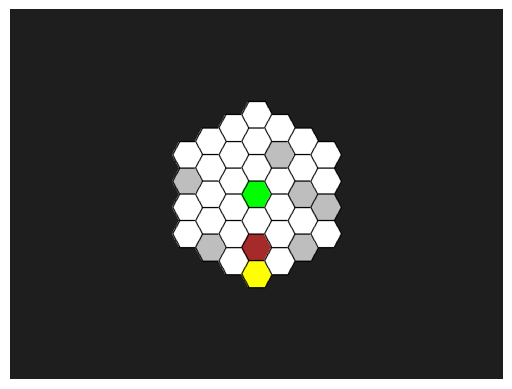

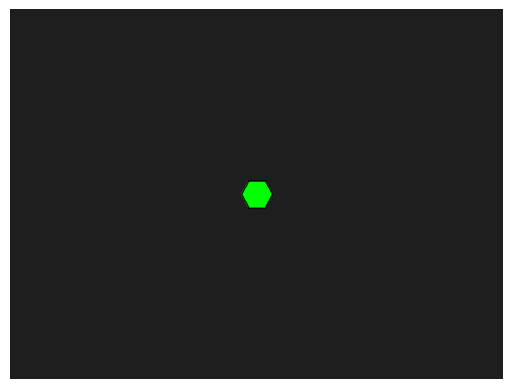

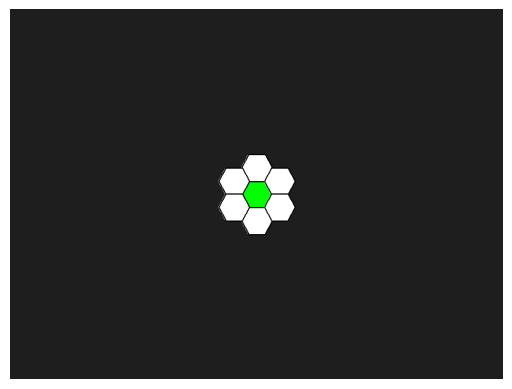

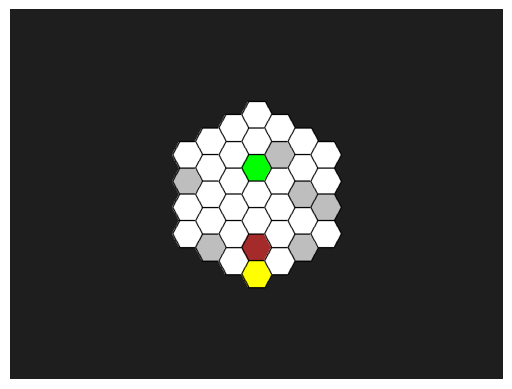

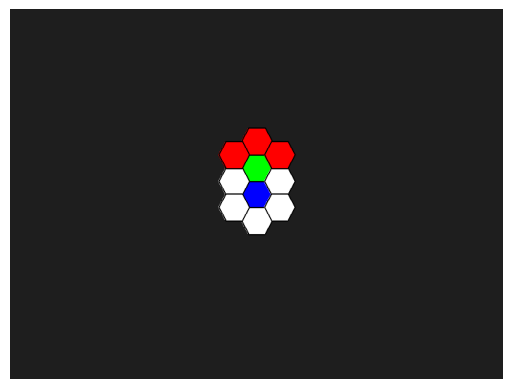

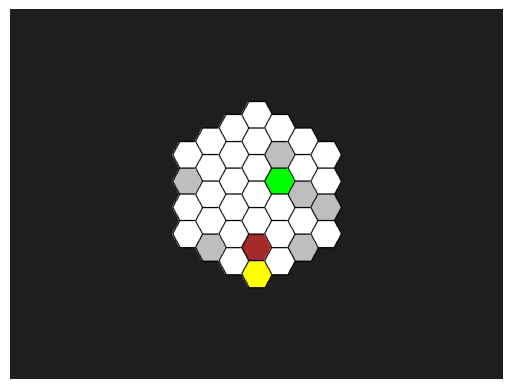

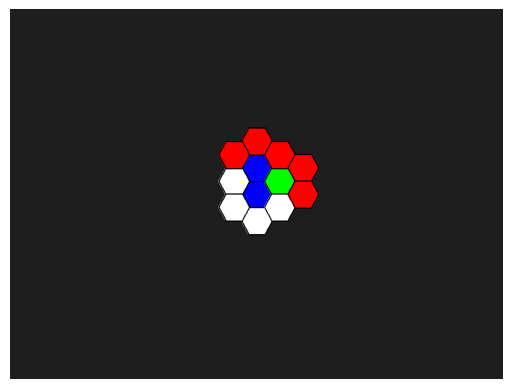

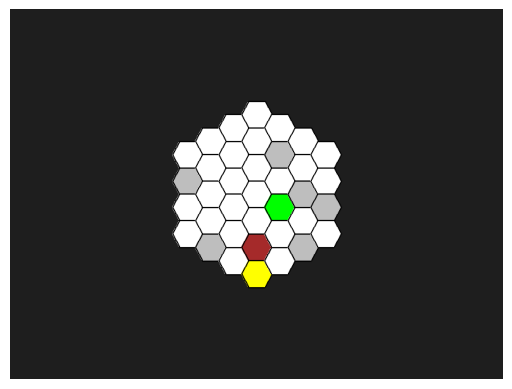

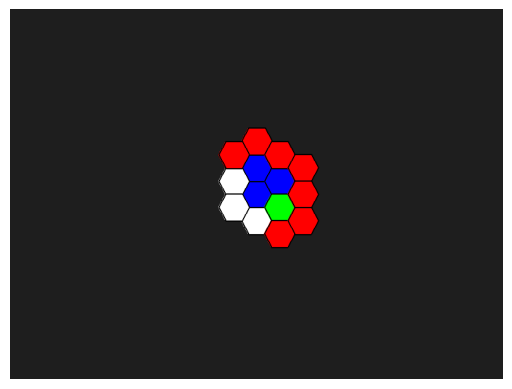

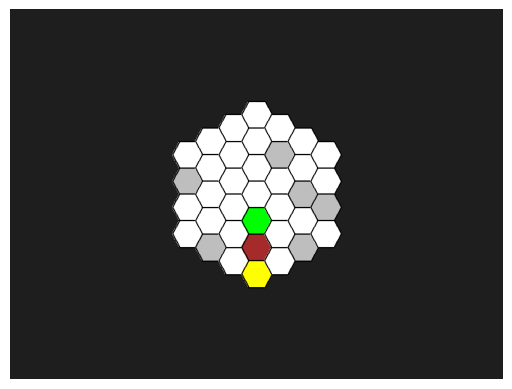

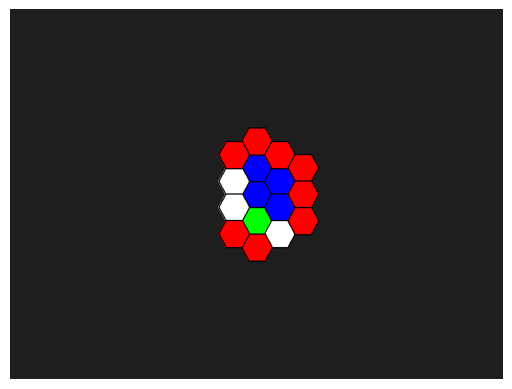

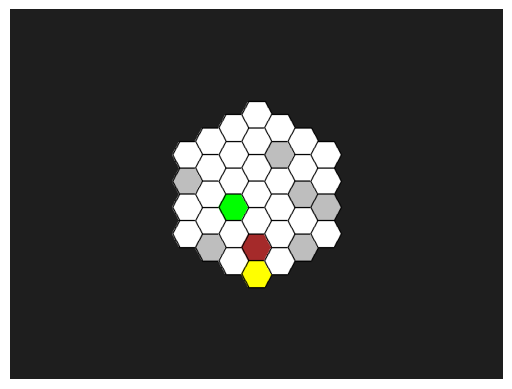

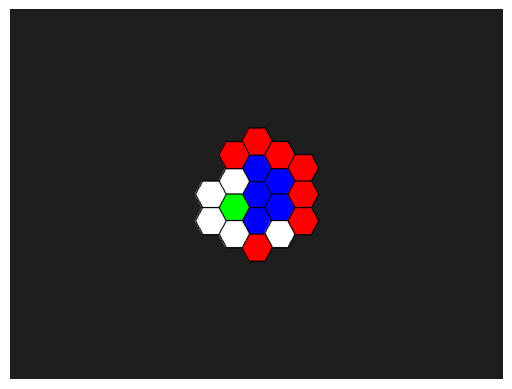

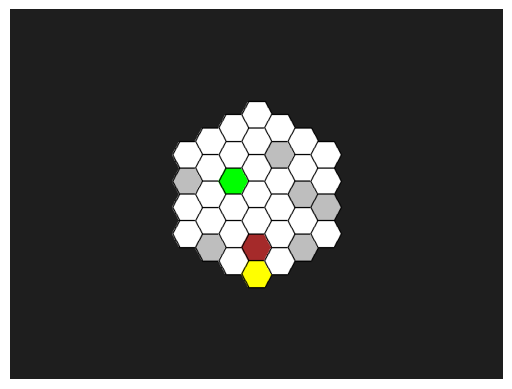

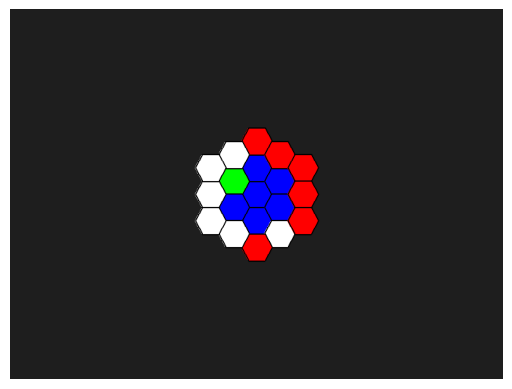

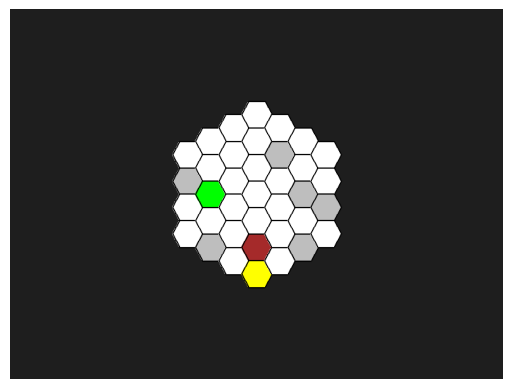

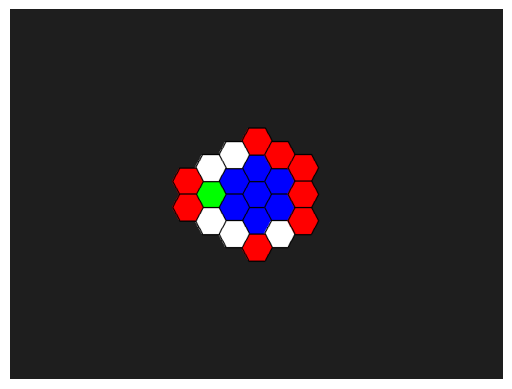

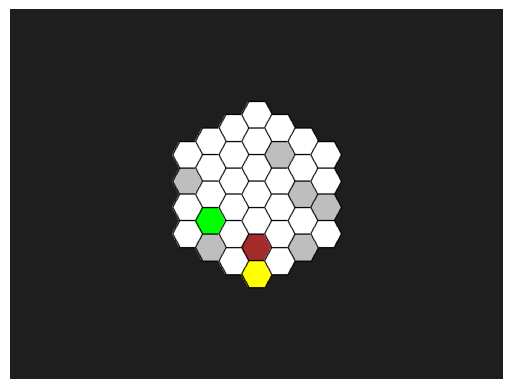

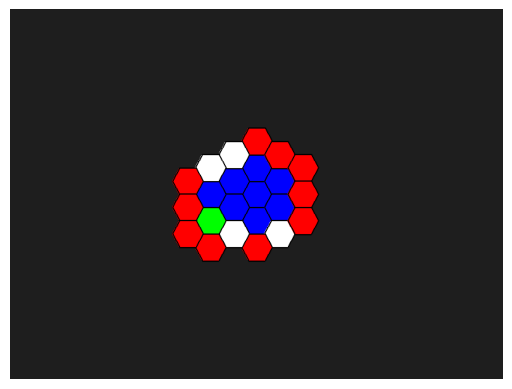

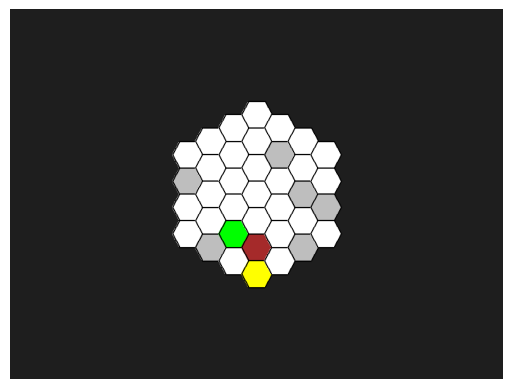

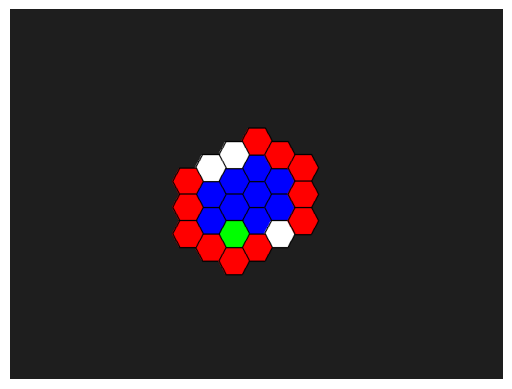

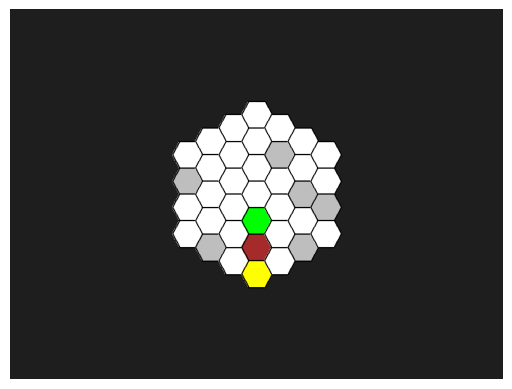

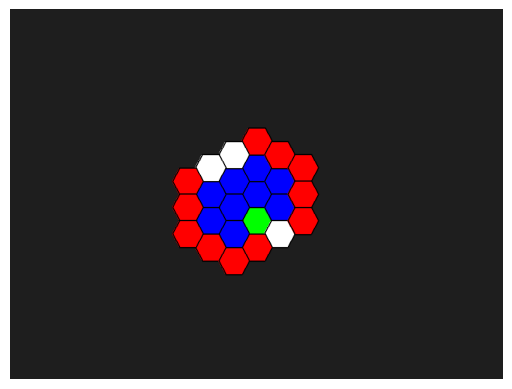

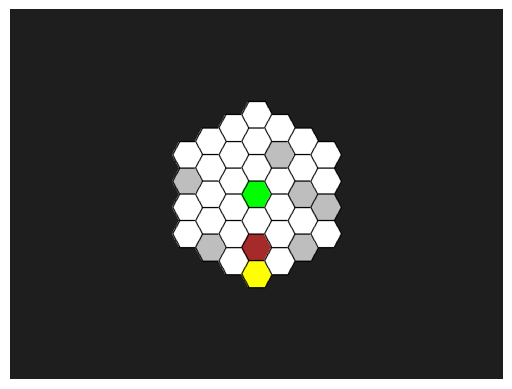

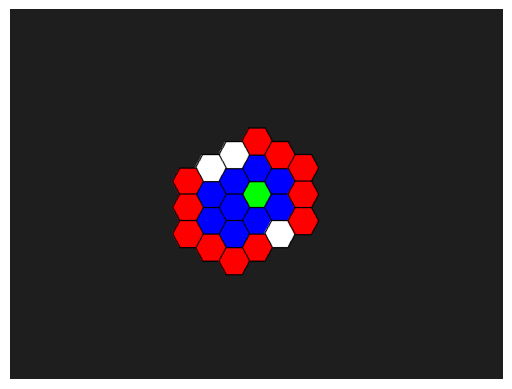

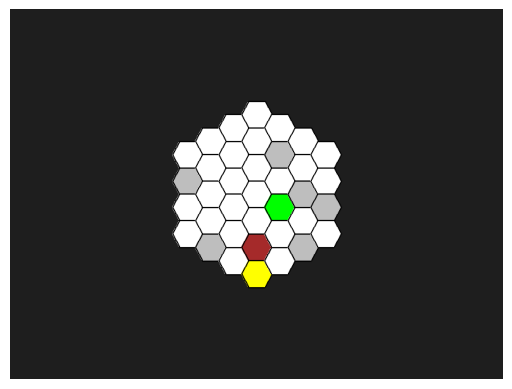

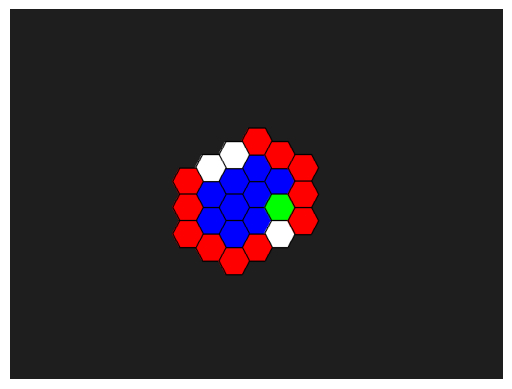

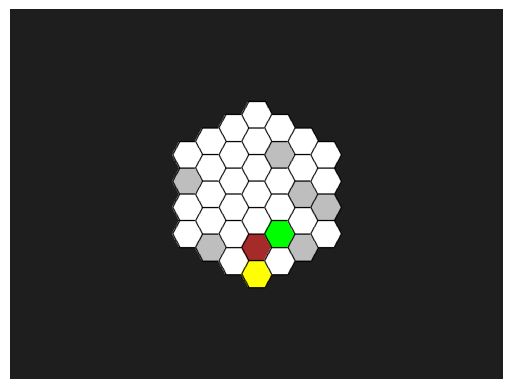

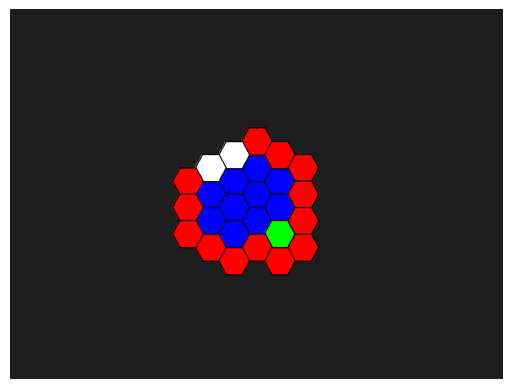

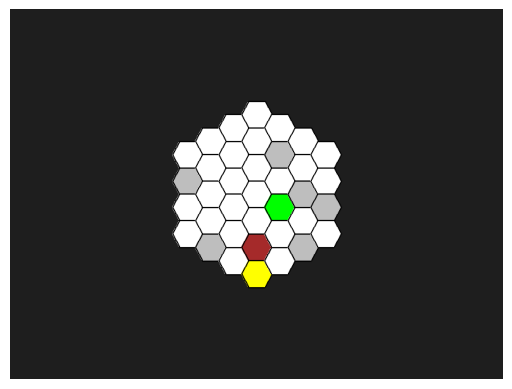

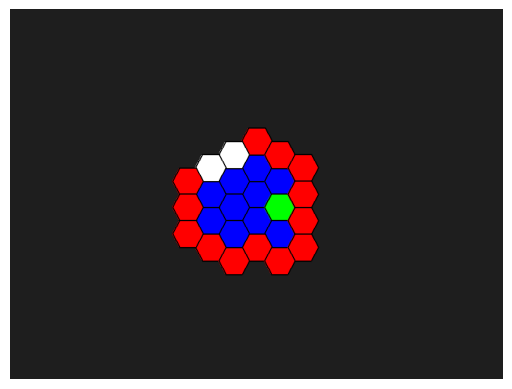

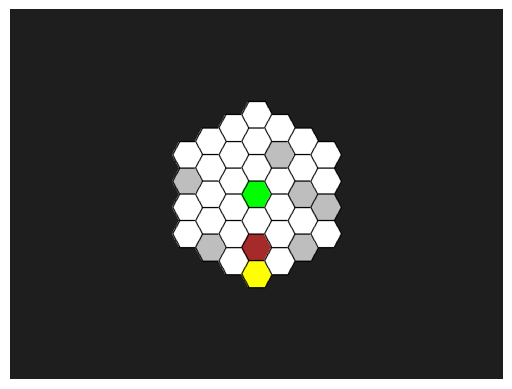

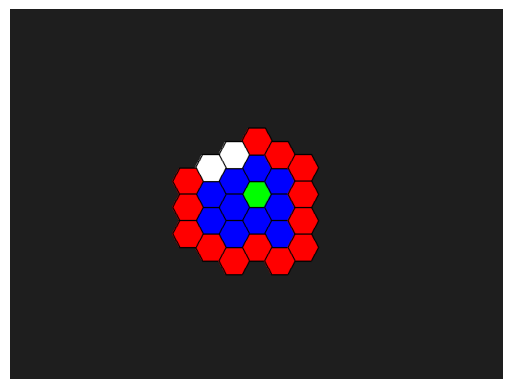

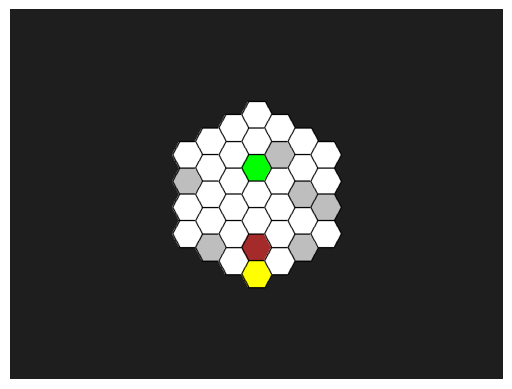

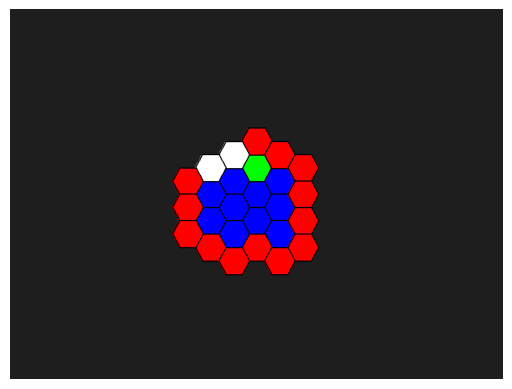

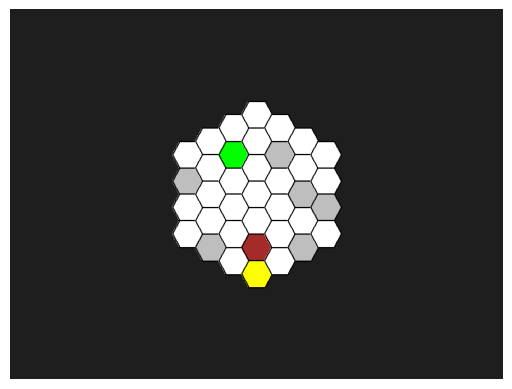

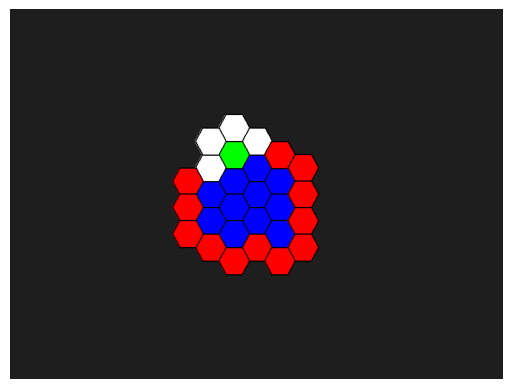

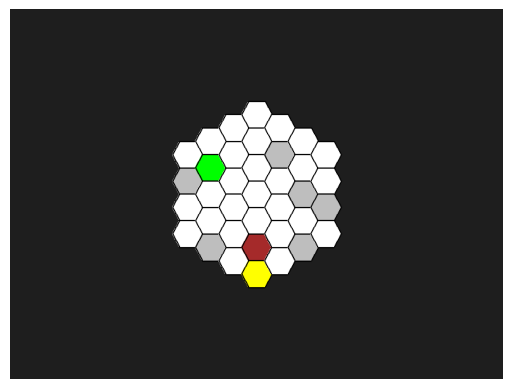

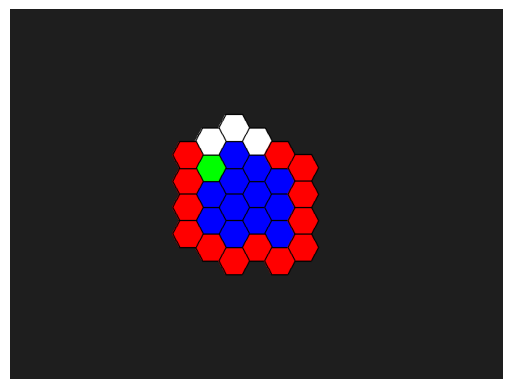

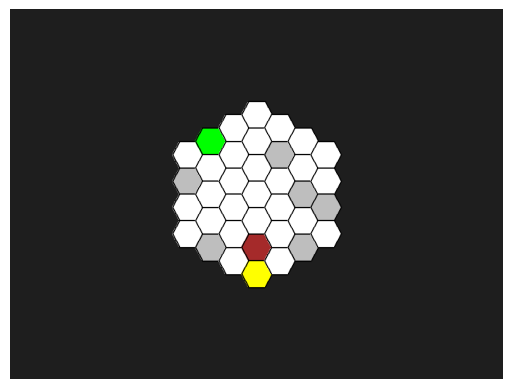

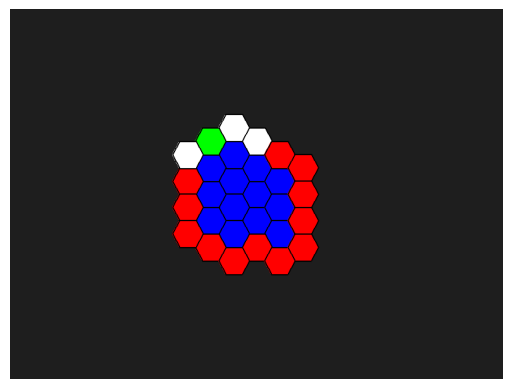

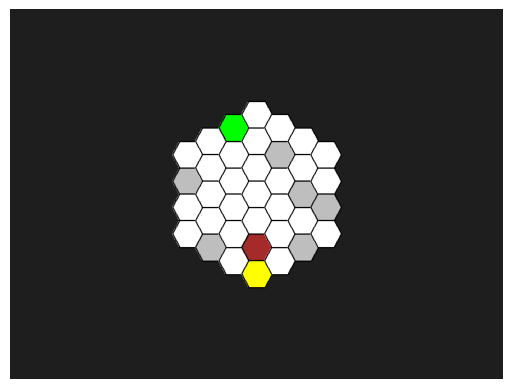

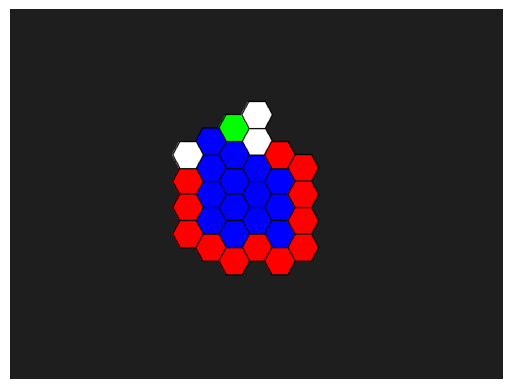

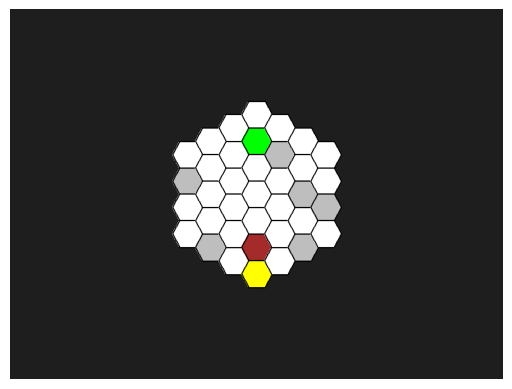

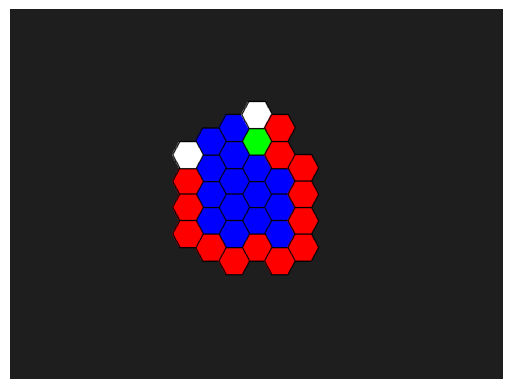

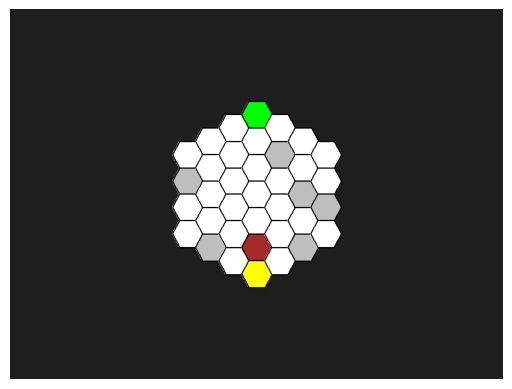

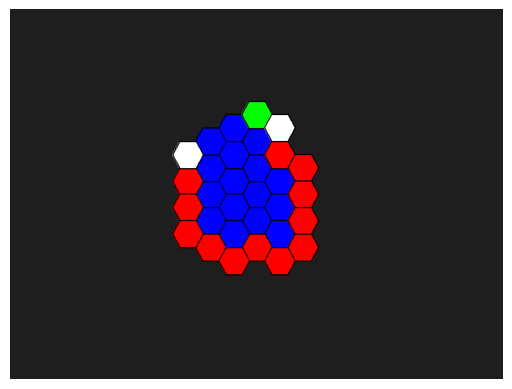

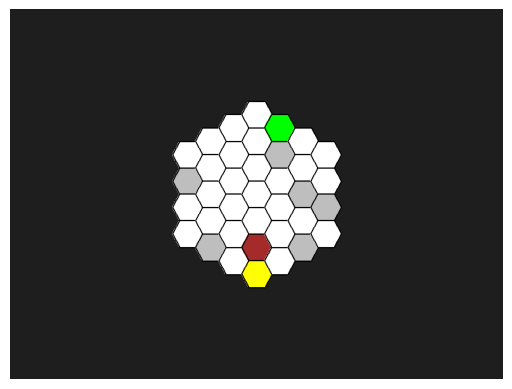

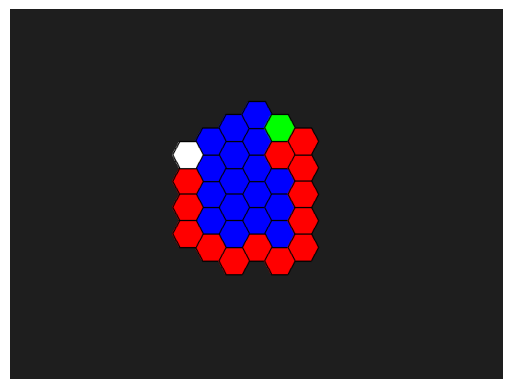

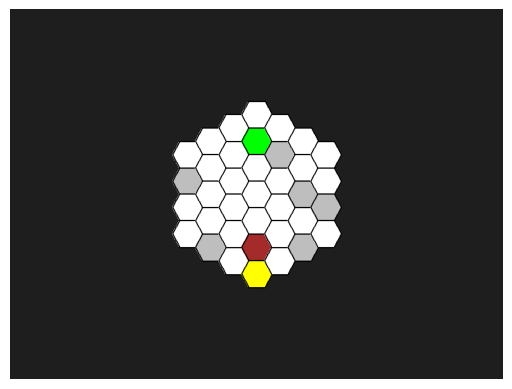

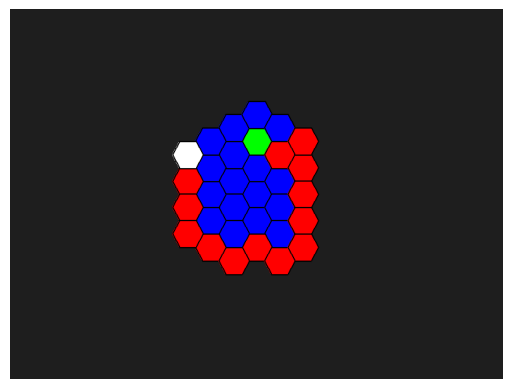

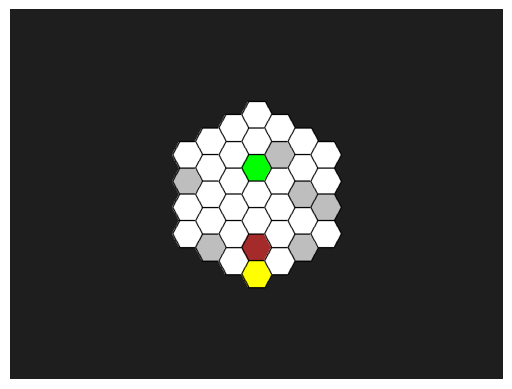

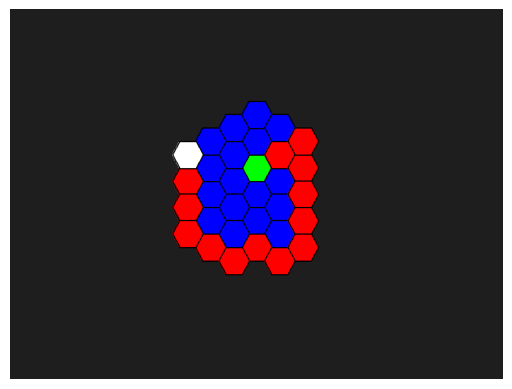

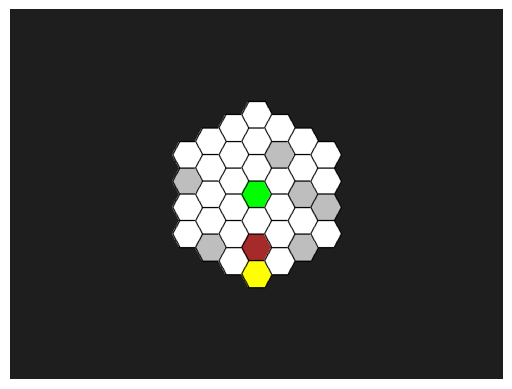

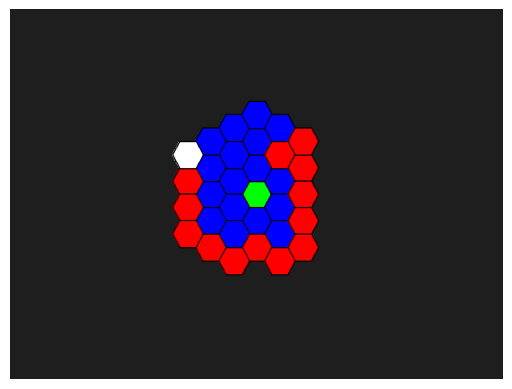

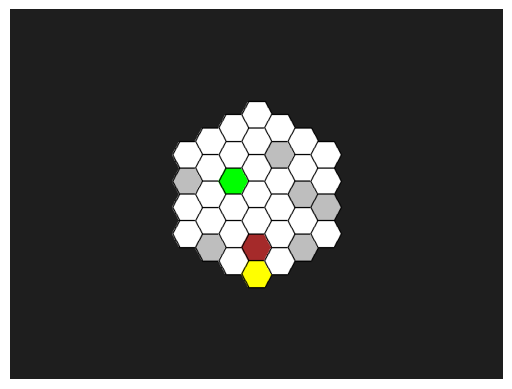

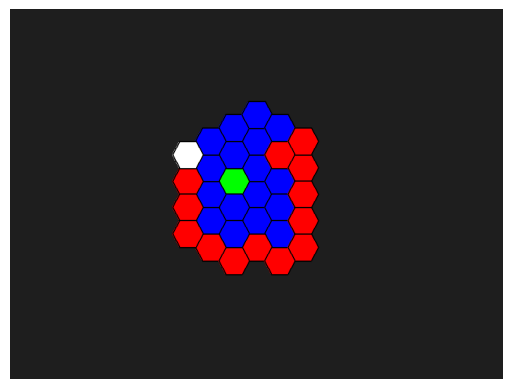

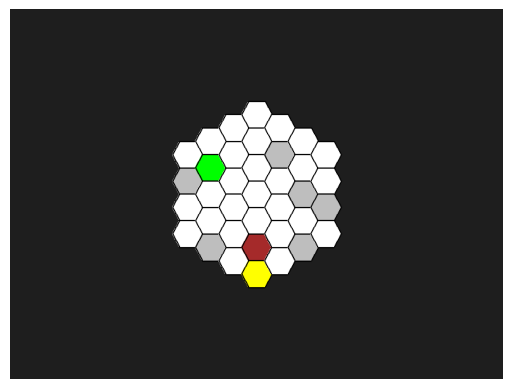

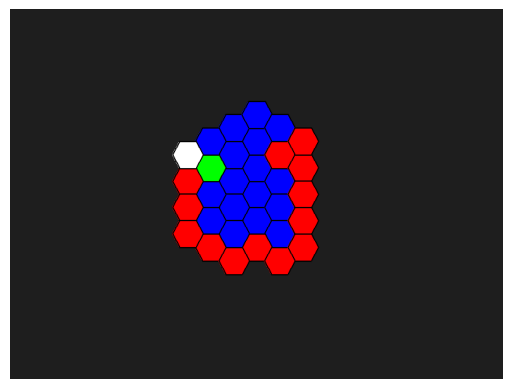

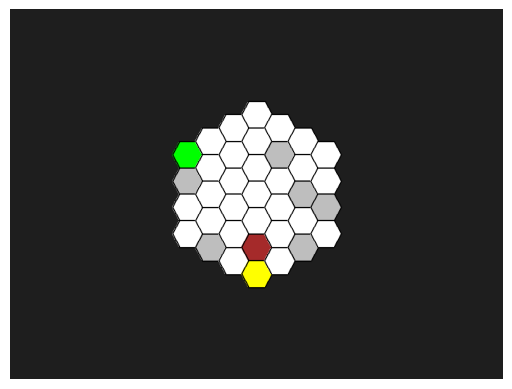

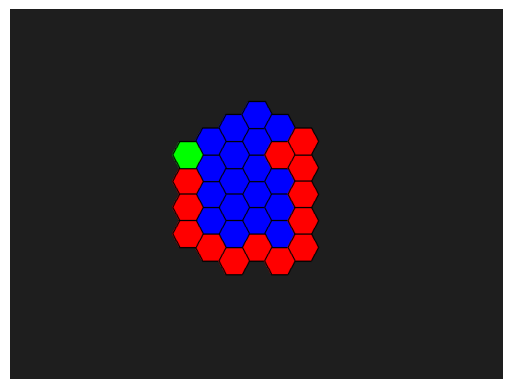

THE WUMPUS MUST DIE


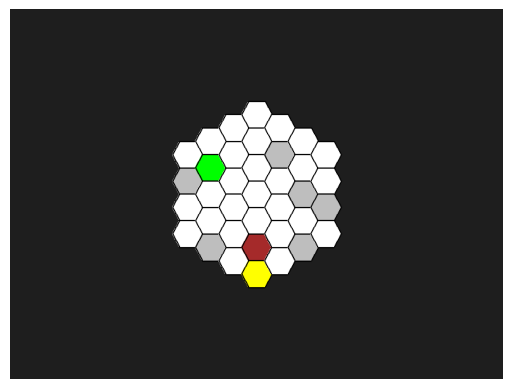

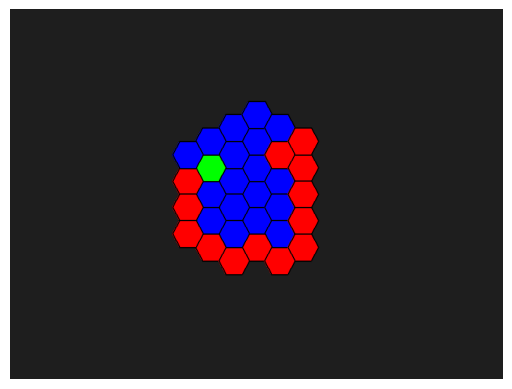

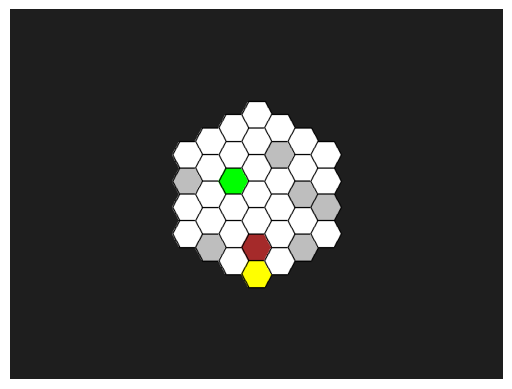

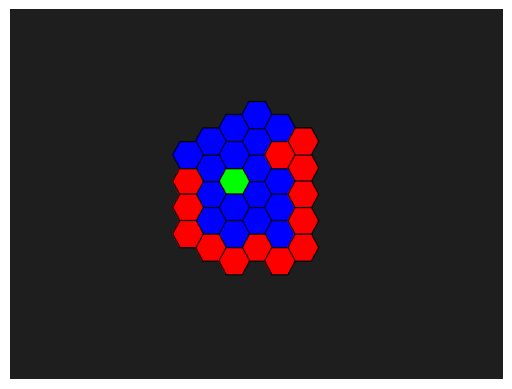

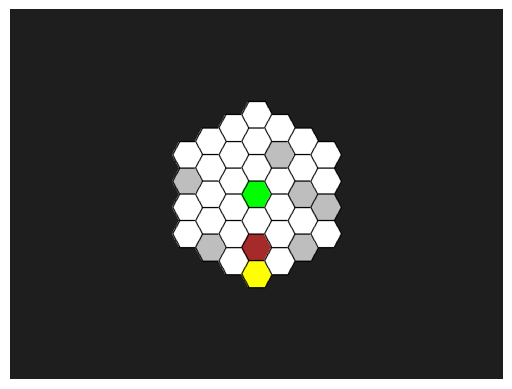

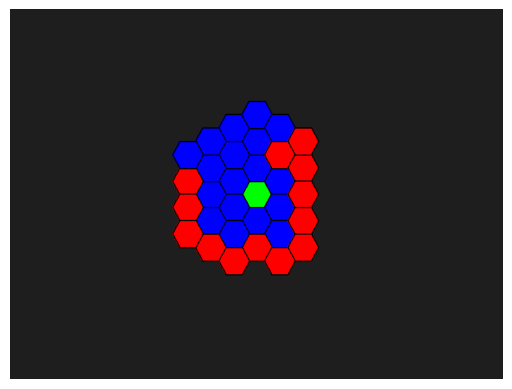

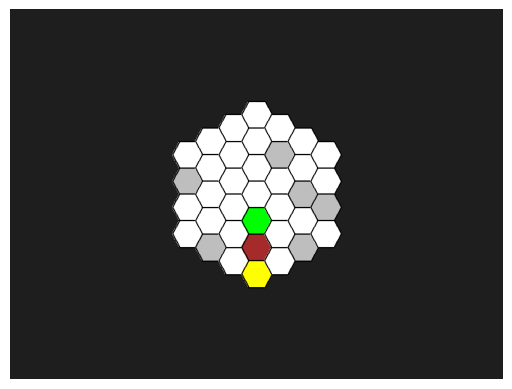

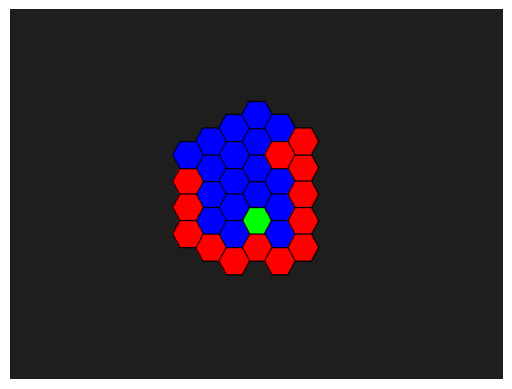

GUN SHOT


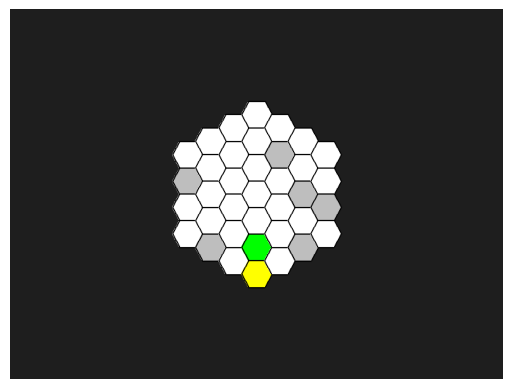

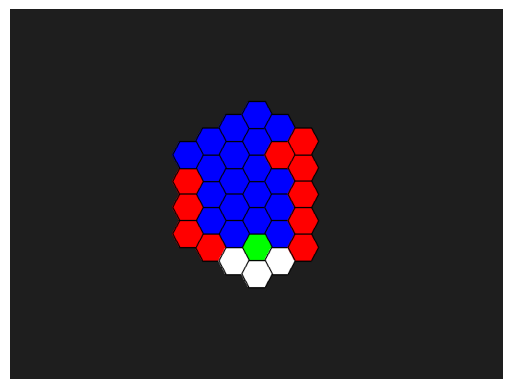

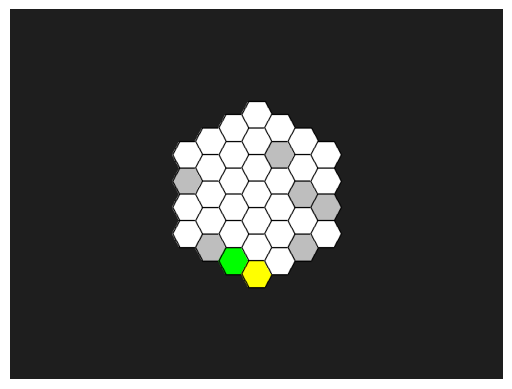

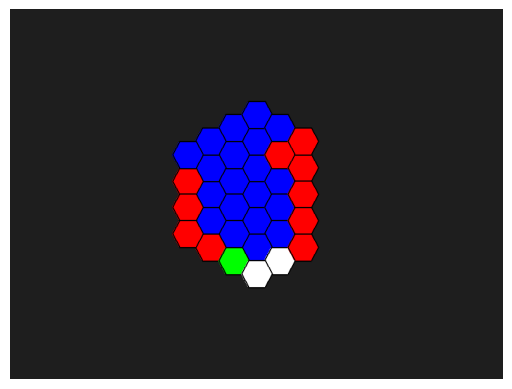

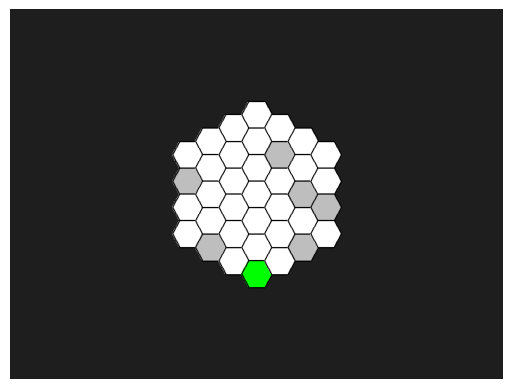

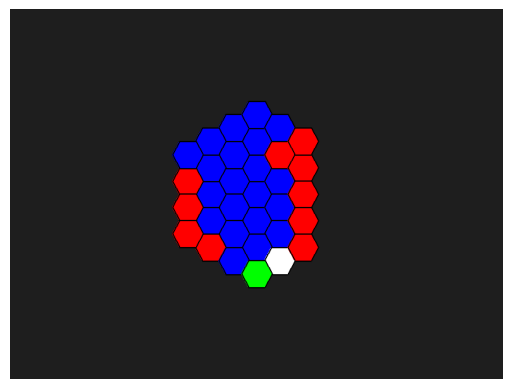

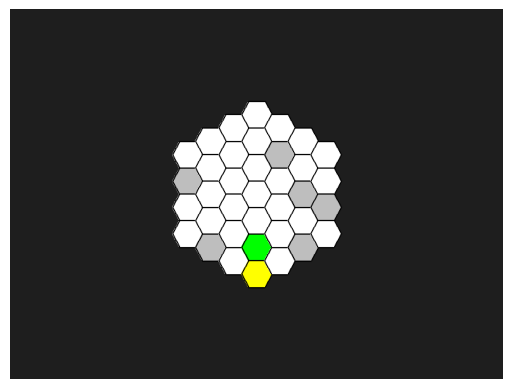

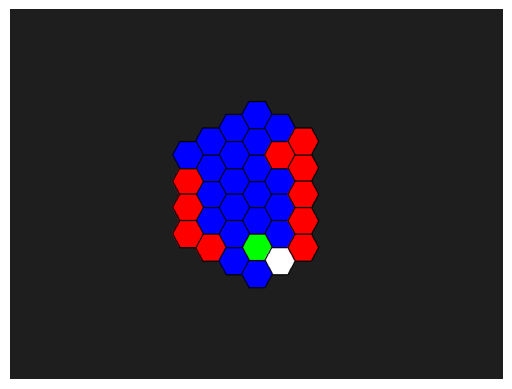

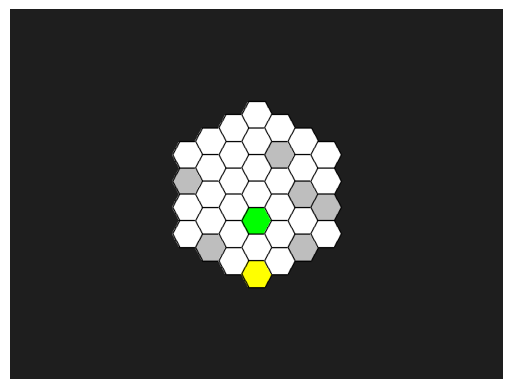

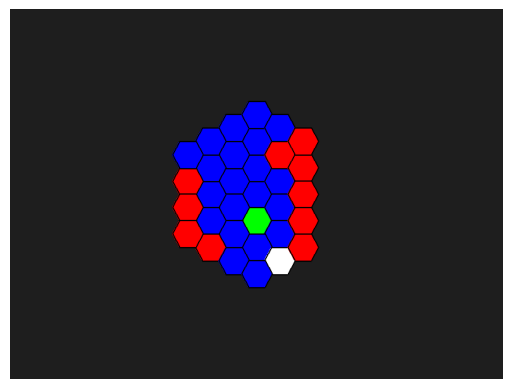

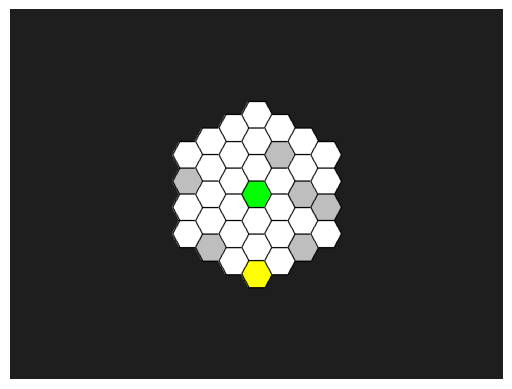

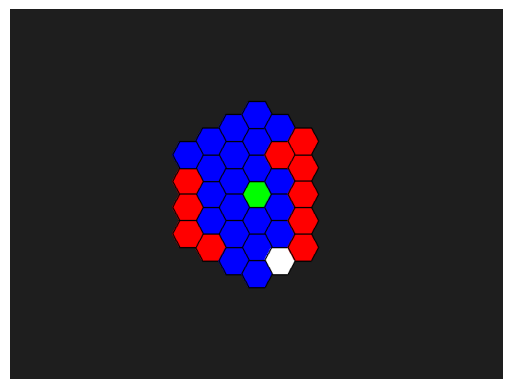

GAME WON


SystemExit: GAME WON

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:

world = let_there_be_light()
print(world.keys())
render(world)
render(agent_map)
wompus_alive = True

agent_map = update_map(agent_map, player_pos, world)
render(agent_map, True)

while True:
  player_pos, to_visit, agent_map, world, wompus_alive = visit_next(player_pos, to_visit, agent_map, world, wompus_alive)